# 📓 Notebook 02 – Feature Extraction
## Lettuce Fresh Weight Prediction | ANN + PSO

**Mode: Local (VS Code)**

Mengekstrak **17 fitur** dari setiap gambar selada:
| Kategori | Fitur |
|----------|-------|
| Morfologi (5) | leaf_area, perimeter, aspect_ratio, extent, equivalent_diameter |
| Warna RGB (3) | mean_R, mean_G, mean_B |
| Warna HSV (3) | mean_H, mean_S, mean_V |
| Tambahan (1)  | std_G |
| Tekstur GLCM (5) | contrast, energy, homogeneity, correlation, entropy |

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, pickle
from tqdm import tqdm
from scipy.stats import entropy as scipy_entropy
from skimage.feature import graycomatrix, graycoprops
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#16213e',
    'axes.labelcolor': 'white', 'xtick.color': 'white',
    'ytick.color': 'white', 'text.color': 'white',
    'axes.edgecolor': '#0f3460', 'grid.color': '#0f3460', 'axes.grid': True,
})
print('✅ Libraries loaded!')

✅ Libraries loaded!


In [2]:
# ── Load konfigurasi dari Notebook 01 ────────────────────
BASE_DIR    = r'D:/laragon/www/lettuce-weight-prediction'
config_path = f'{BASE_DIR}/data/preprocessing_config.pkl'

if os.path.exists(config_path):
    with open(config_path, 'rb') as f:
        config = pickle.load(f)

    lower_green = np.array(config['lower_green'])
    upper_green = np.array(config['upper_green'])

    use_aug = config.get('use_augmented', False)
    if use_aug and 'df_aug_dict' in config:
        df_data = pd.DataFrame(config['df_aug_dict'])
        print(f'📷 Mode: Augmented ({len(df_data)} gambar)')
    else:
        df_data = pd.DataFrame(config['df_valid_dict'])
        print(f'📷 Mode: Original ({len(df_data)} gambar)')

    print(f'✅ Config loaded – HSV {lower_green} → {upper_green}')
else:
    print('⚠️  preprocessing_config.pkl tidak ditemukan!')
    print('   Jalankan 01_Data_Preprocessing.ipynb terlebih dahulu.')
    raise FileNotFoundError(config_path)

FEATURE_COLUMNS = [
    'leaf_area', 'perimeter', 'aspect_ratio', 'extent', 'equivalent_diameter',
    'mean_R', 'mean_G', 'mean_B', 'mean_H', 'mean_S', 'mean_V', 'std_G',
    'contrast', 'energy', 'homogeneity', 'correlation', 'entropy'
]
print(f'🔢 Jumlah fitur: {len(FEATURE_COLUMNS)}')

📷 Mode: Augmented (200 gambar)
✅ Config loaded – HSV [20 30 30] → [ 95 255 255]
🔢 Jumlah fitur: 17


## A. Definisi Fungsi Segmentasi & Ekstraksi

In [3]:
def segment_lettuce(img_bgr, lo=None, hi=None):
    lo = lo if lo is not None else np.array([20, 30, 30])
    hi = hi if hi is not None else np.array([95, 255, 255])
    # Mask akar: gelap (V<65) dan tidak jenuh (S<80) = tanah/akar gelap
    lo_root = np.array([0,  0,  5])
    hi_root = np.array([180, 80, 75])
    hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    mask_g = cv2.inRange(hsv, lo, hi)
    mask_r = cv2.inRange(hsv, lo_root, hi_root)
    mask = cv2.bitwise_or(mask_g, mask_r)
    k_o  = np.ones((3,3), np.uint8)
    k_c  = np.ones((7,7), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  k_o, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k_c, iterations=3)
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if cnts:
        clean = np.zeros_like(mask)
        # Ambil semua blob signifikan (daun + akar), bukan hanya terbesar
        max_area = cv2.contourArea(max(cnts, key=cv2.contourArea))
        for cnt in cnts:
            if cv2.contourArea(cnt) > max(200, max_area * 0.02):
                cv2.drawContours(clean, [cnt], -1, 255, cv2.FILLED)
        mask = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, k_c, iterations=5)
    return mask, cv2.bitwise_and(img_bgr, img_bgr, mask=mask)


def extract_morphological_features(mask):
    """5 fitur morfologi dari binary mask."""
    feat = {'leaf_area': 0.0, 'perimeter': 0.0, 'aspect_ratio': 0.0,
            'extent': 0.0, 'equivalent_diameter': 0.0}
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return feat
    c    = max(cnts, key=cv2.contourArea)
    area = cv2.contourArea(c)
    x, y, w, h = cv2.boundingRect(c)
    feat['leaf_area']           = float(area)
    feat['perimeter']           = float(cv2.arcLength(c, True))
    feat['aspect_ratio']        = float(w / h) if h > 0 else 0.0
    feat['extent']              = float(area / (w * h)) if w * h > 0 else 0.0
    feat['equivalent_diameter'] = float(np.sqrt(4 * area / np.pi)) if area > 0 else 0.0
    return feat


def extract_color_features(img_bgr, mask):
    """7 fitur warna: RGB + HSV + std_G."""
    feat = {k: 0.0 for k in ['mean_R','mean_G','mean_B','mean_H','mean_S','mean_V','std_G']}
    mb   = mask > 0
    if not mb.any(): return feat
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    feat['mean_R'] = float(rgb[:,:,0][mb].mean())
    feat['mean_G'] = float(rgb[:,:,1][mb].mean())
    feat['mean_B'] = float(rgb[:,:,2][mb].mean())
    feat['std_G']  = float(rgb[:,:,1][mb].std())
    feat['mean_H'] = float(hsv[:,:,0][mb].mean())
    feat['mean_S'] = float(hsv[:,:,1][mb].mean())
    feat['mean_V'] = float(hsv[:,:,2][mb].mean())
    return feat


def extract_texture_features(img_bgr, mask):
    """5 fitur tekstur GLCM."""
    feat = {k: 0.0 for k in ['contrast','energy','homogeneity','correlation','entropy']}
    if not (mask > 0).any(): return feat
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gm   = cv2.bitwise_and(gray, gray, mask=mask)
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return feat
    x, y, w, h = cv2.boundingRect(max(cnts, key=cv2.contourArea))
    roi = gm[y:y+h, x:x+w]
    if roi.shape[0] < 2 or roi.shape[1] < 2: return feat
    try:
        q    = (roi // 32).astype(np.uint8)
        glcm = graycomatrix(q, [1], [0, np.pi/4, np.pi/2, 3*np.pi/4],
                            levels=8, symmetric=True, normed=True)
        feat['contrast']    = float(np.mean(graycoprops(glcm, 'contrast')))
        feat['energy']      = float(np.mean(graycoprops(glcm, 'energy')))
        feat['homogeneity'] = float(np.mean(graycoprops(glcm, 'homogeneity')))
        feat['correlation'] = float(np.mean(graycoprops(glcm, 'correlation')))
        h_arr  = np.histogram(roi[roi > 0], bins=256, range=(0,256))[0]
        feat['entropy'] = float(scipy_entropy(h_arr / (h_arr.sum() + 1e-10) + 1e-10))
    except: pass
    return feat


print('✅ Semua fungsi berhasil didefinisikan!')

# Quick test
row0 = df_data.iloc[0]
img0 = cv2.resize(cv2.imread(row0['image_path']), (640, 480))
m0, _ = segment_lettuce(img0, lower_green, upper_green)
print(f'   Test {row0["id"]}: coverage={np.count_nonzero(m0)/m0.size*100:.1f}%')
print(f'   Morfologi : {extract_morphological_features(m0)}')

✅ Semua fungsi berhasil didefinisikan!
   Test S001: coverage=16.5%
   Morfologi : {'leaf_area': 50037.0, 'perimeter': 1395.0437175035477, 'aspect_ratio': 2.5970873786407767, 'extent': 0.4540150621540695, 'equivalent_diameter': 252.4065908408759}


## B. Ekstraksi Semua Gambar

In [4]:
print(f'🔄 Mengekstrak fitur dari {len(df_data)} gambar...')

rows   = []
failed = []

for _, row in tqdm(df_data.iterrows(), total=len(df_data), desc='Extracting Features'):
    try:
        img = cv2.imread(row['image_path'])
        if img is None:
            failed.append(row['image_path']); continue

        img  = cv2.resize(img, (640, 480))
        mask, _ = segment_lettuce(img, lower_green, upper_green)

        if np.count_nonzero(mask) / mask.size < 0.005:
            failed.append(row['image_path']); continue

        feat = {}
        feat.update(extract_morphological_features(mask))
        feat.update(extract_color_features(img, mask))
        feat.update(extract_texture_features(img, mask))
        feat['weight_gram'] = float(row['weight_gram'])
        feat['image_id']    = row.get('id', '')
        rows.append(feat)
    except Exception as e:
        failed.append(str(row.get('image_path', '?')))

df_feat = pd.DataFrame(rows)
print(f'\n✅ Berhasil : {len(df_feat)}')
print(f'❌ Gagal    : {len(failed)}')
if failed:
    print('   File yang gagal:')
    for f in failed[:5]: print(f'   - {os.path.basename(f)}')

🔄 Mengekstrak fitur dari 200 gambar...


Extracting Features: 100%|██████████| 200/200 [00:13<00:00, 15.35it/s]


✅ Berhasil : 200
❌ Gagal    : 0


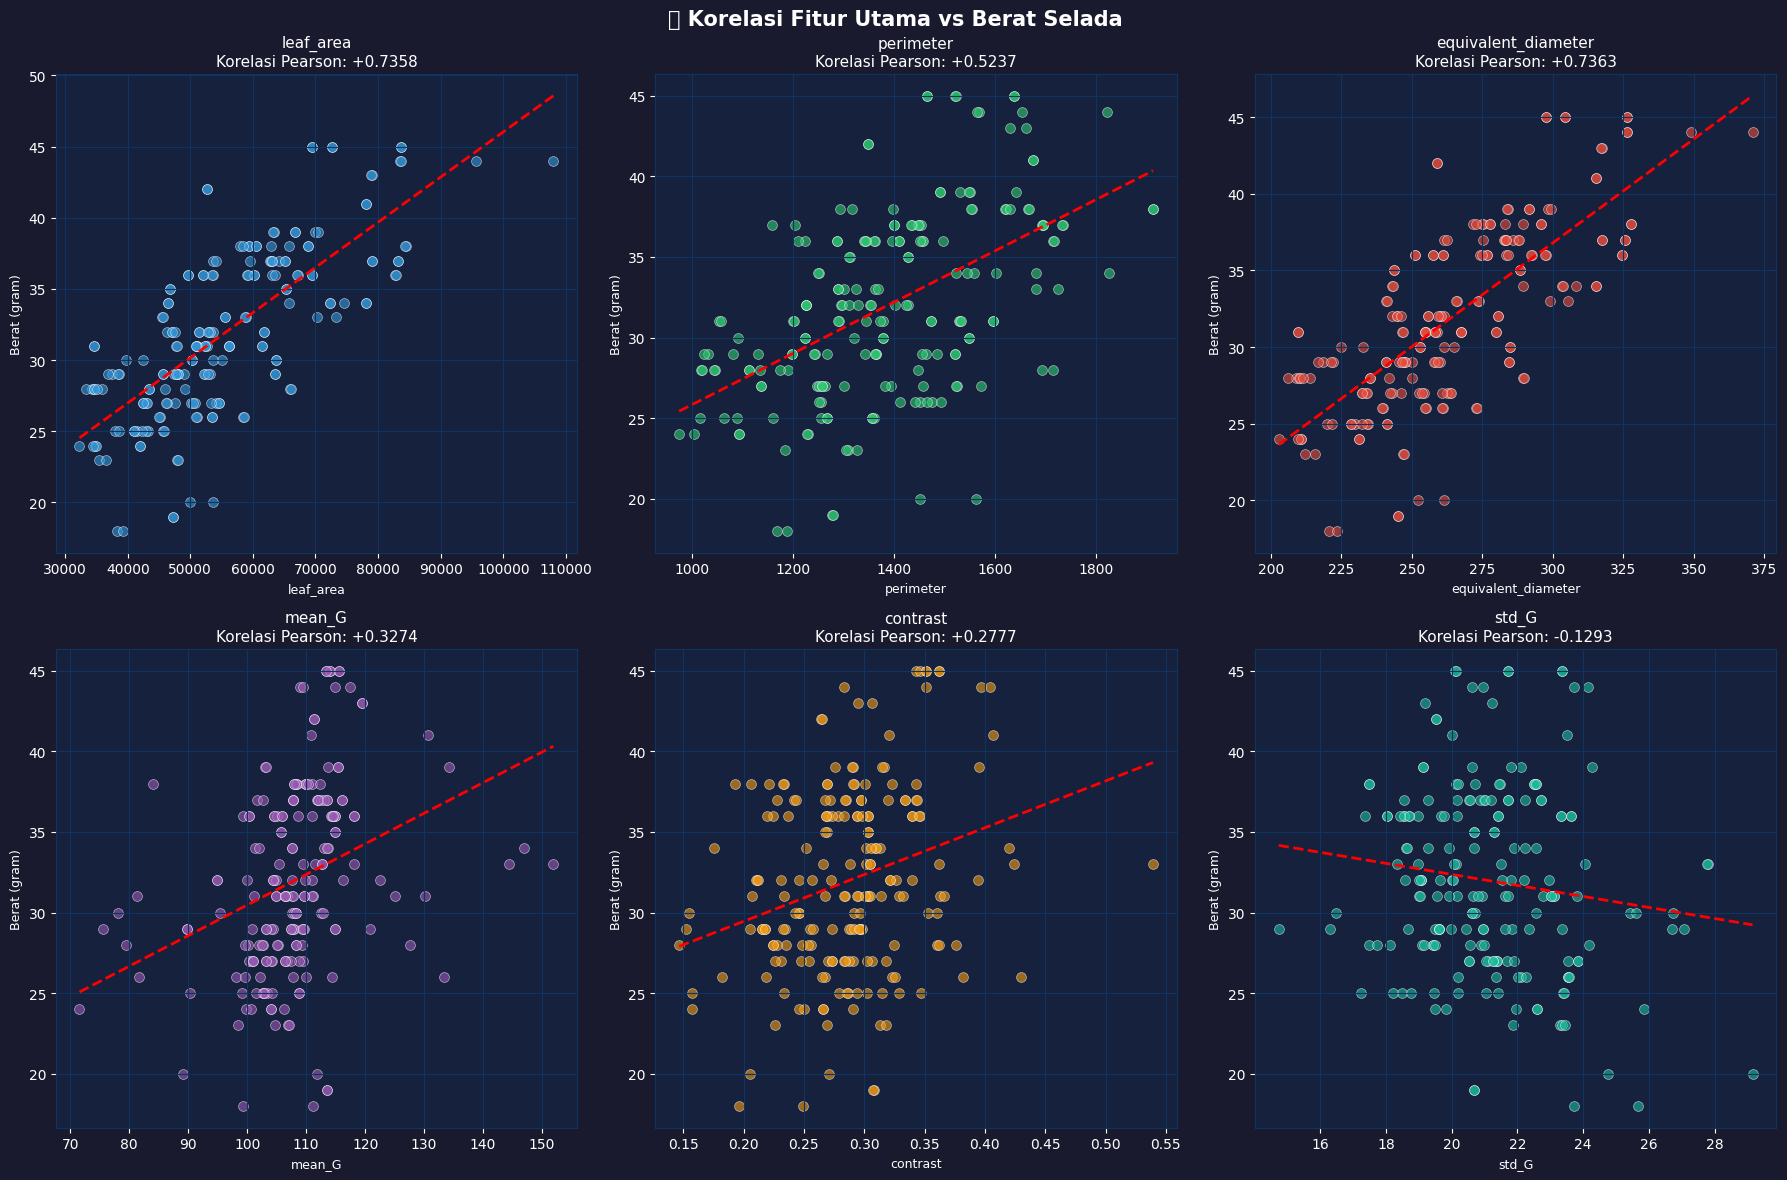

✅ Plot disimpan → output/plots/feature_vs_weight.png


In [5]:
# Visualisasi korelasi fitur utama vs berat
key_feats = ['leaf_area', 'perimeter', 'equivalent_diameter', 'mean_G', 'contrast', 'std_G']
colors    = ['#3498DB','#2ECC71','#E74C3C','#9B59B6','#F39C12','#1ABC9C']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('📊 Korelasi Fitur Utama vs Berat Selada', fontsize=15, fontweight='bold', color='white')

for ax, feat, color in zip(axes.flatten(), key_feats, colors):
    corr = df_feat[feat].corr(df_feat['weight_gram'])
    ax.scatter(df_feat[feat], df_feat['weight_gram'],
               alpha=0.6, s=50, color=color, edgecolors='white', lw=0.5)
    z = np.polyfit(df_feat[feat], df_feat['weight_gram'], 1)
    x_line = np.linspace(df_feat[feat].min(), df_feat[feat].max(), 100)
    ax.plot(x_line, np.poly1d(z)(x_line), 'r--', linewidth=2)
    ax.set_title(f'{feat}\nKorelasi Pearson: {corr:+.4f}', fontsize=11)
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('Berat (gram)', fontsize=9)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/output/plots/feature_vs_weight.png',
            dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('✅ Plot disimpan → output/plots/feature_vs_weight.png')

In [6]:
# Bersihkan NaN, simpan dataset
df_final = df_feat[FEATURE_COLUMNS + ['weight_gram']].copy()
for col in FEATURE_COLUMNS:
    n_nan = df_final[col].isna().sum()
    if n_nan > 0:
        df_final[col] = df_final[col].fillna(df_final[col].median())
        print(f'  Filled {n_nan} NaN in {col}')

out_path = f'{BASE_DIR}/data/dataset.csv'
df_final.to_csv(out_path, index=False)

print('=' * 55)
print('✅ NOTEBOOK 02 SELESAI!')
print('=' * 55)
print(f'  Dataset   : {out_path}')
print(f'  Sampel    : {len(df_final)}')
print(f'  Fitur     : {len(FEATURE_COLUMNS)}')
print(f'  Berat     : {df_final["weight_gram"].min():.1f}g – {df_final["weight_gram"].max():.1f}g')
print()
print('🔢 Korelasi fitur vs berat:')
for feat in FEATURE_COLUMNS:
    c   = df_final[feat].corr(df_final['weight_gram'])
    bar = '█' * int(abs(c) * 15)
    print(f'  {feat:25s}: {"+" if c>0 else "-"}{abs(c):.4f} |{bar}')
print()
print('📌 Lanjut → 03_Exploratory_Data_Analysis.ipynb')

✅ NOTEBOOK 02 SELESAI!
  Dataset   : D:/laragon/www/lettuce-weight-prediction/data/dataset.csv
  Sampel    : 200
  Fitur     : 17
  Berat     : 18.0g – 45.0g

🔢 Korelasi fitur vs berat:
  leaf_area                : +0.7358 |███████████
  perimeter                : +0.5237 |███████
  aspect_ratio             : +0.2195 |███
  extent                   : +0.3645 |█████
  equivalent_diameter      : +0.7363 |███████████
  mean_R                   : +0.1777 |██
  mean_G                   : +0.3274 |████
  mean_B                   : -0.2195 |███
  mean_H                   : +0.4317 |██████
  mean_S                   : +0.6106 |█████████
  mean_V                   : +0.3118 |████
  std_G                    : -0.1293 |█
  contrast                 : +0.2777 |████
  energy                   : -0.3562 |█████
  homogeneity              : -0.4636 |██████
  correlation              : -0.0966 |█
  entropy                  : +0.0620 |

📌 Lanjut → 03_Exploratory_Data_Analysis.ipynb
